<a href="https://colab.research.google.com/github/mszhdgr/Machine_learning/blob/Main/Clustering/School_enrollment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mohamedasak/online-learning-student-dropout-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'online-learning-student-dropout-dataset' dataset.
Path to dataset files: /kaggle/input/online-learning-student-dropout-dataset


In [3]:
import pandas as pd

df = pd.read_csv("/kaggle/input/online-learning-student-dropout-dataset/student_dropout_dataset.csv")
df.head()

,student_id,age,region,enroll_date,exam_season,courses_enrolled,completed_assignments,completion_rate,login_frequency,last_activity_days_ago,forum_posts_count,dropout_score,label,label_multiclass,label_name
0,STU00001,26,Alexandria,2024-01-13,0,3,5,0.3571,5.29,10,5,0.1064,0,0,active
1,STU00002,23,Amman,2024-05-05,0,6,0,0.0000,0.84,7,0,0.6627,1,2,dropped
2,STU00003,17,Dubai,2024-03-12,0,3,1,0.0435,1.79,36,0,0.7299,1,2,dropped
3,STU00004,23,Alexandria,2024-12-12,0,6,13,0.4396,0.78,9,0,0.5315,1,1,at-risk
4,STU00005,20,Baghdad,2024-02-14,0,5,5,0.2078,0.92,11,0,0.7904,1,2,dropped


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   student_id              5000 non-null   object 
 1   age                     5000 non-null   int64  
 2   region                  5000 non-null   object 
 3   enroll_date             5000 non-null   object 
 4   exam_season             5000 non-null   int64  
 5   courses_enrolled        5000 non-null   int64  
 6   completed_assignments   5000 non-null   int64  
 7   completion_rate         5000 non-null   float64
 8   login_frequency         5000 non-null   float64
 9   last_activity_days_ago  5000 non-null   int64  
 10  forum_posts_count       5000 non-null   int64  
 11  dropout_score           5000 non-null   float64
 12  label                   5000 non-null   int64  
 13  label_multiclass        5000 non-null   int64  
 14  label_name              5000 non-null   

In [5]:
df.describe()

,age,exam_season,courses_enrolled,completed_assignments,completion_rate,login_frequency,last_activity_days_ago,forum_posts_count,dropout_score,label,label_multiclass
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000,5000.000000,5000.000000
mean,23.736600,0.094000,3.999400,5.188400,0.260985,3.453820,9.3564,4.212200,0.431556,0.659200,0.985800
std,4.583211,0.291858,1.997348,6.109466,0.249010,3.248316,9.4361,4.270131,0.263529,0.474026,0.816904
min,17.000000,0.000000,1.000000,0.000000,0.000000,0.100000,1.0000,0.000000,0.000000,0.000000,0.000000
25%,20.000000,0.000000,2.000000,1.000000,0.053900,0.980000,2.0000,1.000000,0.204575,0.000000,0.000000
50%,24.000000,0.000000,4.000000,3.000000,0.206700,2.440000,6.0000,3.000000,0.441550,1.000000,1.000000
75%,27.000000,0.000000,6.000000,7.000000,0.389025,4.942500,13.0000,6.000000,0.658325,1.000000,2.000000
max,40.000000,1.000000,7.000000,35.000000,1.000000,14.000000,70.0000,24.000000,1.000000,1.000000,2.000000


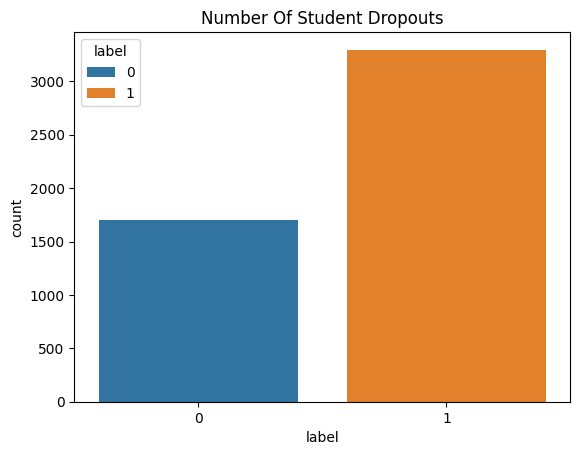

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(df, x="label", hue="label")
plt.title("Number Of Student Dropouts")
plt.show()

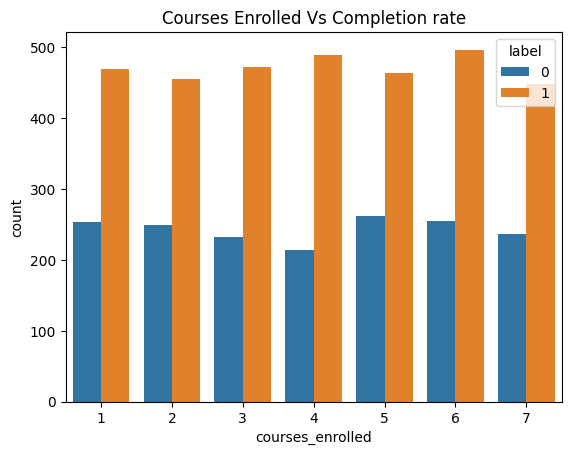

In [51]:
sns.countplot(df, x="courses_enrolled", hue="label")
plt.title("Courses Enrolled Vs Completion rate")
plt.show()

In [68]:
df['label'].value_counts()

,count
label,
1,3296
0,1704


In [70]:
features = ["courses_enrolled","login_frequency","last_activity_days_ago", "label_multiclass"]
x = pd.DataFrame(df, columns=features)
x

,courses_enrolled,login_frequency,last_activity_days_ago,label_multiclass
0,3,5.29,10,0
1,6,0.84,7,2
2,3,1.79,36,2
3,6,0.78,9,1
4,5,0.92,11,2
...,...,...,...,...
4995,2,11.06,1,0
4996,2,5.16,15,1
4997,3,5.05,5,0
4998,1,4.04,1,0


In [71]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 10))
scalled_features = scaler.fit_transform(x)
scalled_features

array([[ 3.33333333,  3.73381295,  1.30434783,  0.        ],
       [ 8.33333333,  0.5323741 ,  0.86956522, 10.        ],
       [ 3.33333333,  1.21582734,  5.07246377, 10.        ],
       ...,
       [ 3.33333333,  3.56115108,  0.57971014,  0.        ],
       [ 0.        ,  2.83453237,  0.        ,  0.        ],
       [ 0.        ,  2.39568345,  0.        ,  0.        ]])

In [69]:
from sklearn.cluster import KMeans

inertia = []
k_range = range(1, 11)
k_range

range(1, 11)

In [72]:
for i in k_range:
  kmeans = KMeans(n_clusters=i)
  kmeans.fit(scalled_features)
  inertia.append(kmeans.inertia_)

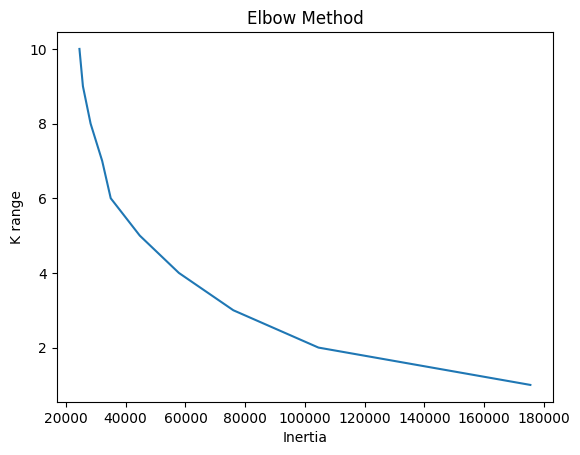

In [76]:
plt.plot(inertia, k_range)
plt.title("Elbow Method")
plt.ylabel("K range")
plt.xlabel("Inertia")
plt.show()

In [77]:
model = KMeans(n_clusters=4)
model.fit(scalled_features)

KMeans(n_clusters=4)

In [78]:
model.labels_

array([2, 3, 3, ..., 2, 2, 2], dtype=int32)

In [79]:
model.cluster_centers_

array([[ 8.59358145,  3.40294754,  1.15390929,  2.18042071],
       [ 3.11270125,  1.73195969,  1.10367893,  5.        ],
       [ 2.61763738,  4.96309132,  1.04611071,  0.029615  ],
       [ 5.04694836,  0.54752915,  1.43019427, 10.        ]])

In [82]:
labels = model.labels_
labels

array([2, 3, 3, ..., 2, 2, 2], dtype=int32)

In [83]:
x["predicted_label"] = labels

In [84]:
x.head()

,courses_enrolled,login_frequency,last_activity_days_ago,label_multiclass,predicted_label
0,3,5.29,10,0,2
1,6,0.84,7,2,3
2,3,1.79,36,2,3
3,6,0.78,9,1,0
4,5,0.92,11,2,3


In [89]:
x[x['predicted_label'] == 0]

,courses_enrolled,login_frequency,last_activity_days_ago,label_multiclass,predicted_label
3,6,0.78,9,1,0
8,7,5.91,4,1,0
9,5,4.58,5,0,0
17,6,1.78,11,1,0
19,7,9.66,10,0,0
...,...,...,...,...,...
4970,6,5.17,1,0,0
4982,5,8.39,6,0,0
4983,5,3.18,28,1,0
4985,7,3.64,9,0,0


In [93]:
x[x['predicted_label'] == 0].describe()

,courses_enrolled,login_frequency,last_activity_days_ago,label_multiclass,predicted_label
count,1240.000000,1240.000000,1240.000000,1240.000000,1240.0
mean,6.152419,4.825089,8.968548,0.437903,0.0
std,0.761351,2.938776,9.125958,0.496329,0.0
min,5.000000,0.120000,1.000000,0.000000,0.0
25%,6.000000,2.660000,2.000000,0.000000,0.0
50%,6.000000,4.140000,6.000000,0.000000,0.0
75%,7.000000,6.320000,12.000000,1.000000,0.0
max,7.000000,14.000000,66.000000,1.000000,0.0


In [90]:
x[x['predicted_label'] == 1]

,courses_enrolled,login_frequency,last_activity_days_ago,label_multiclass,predicted_label
13,3,1.89,7,1,1
16,5,2.35,13,1,1
32,4,1.84,2,1,1
33,5,1.15,4,1,1
40,4,10.23,26,1,1
...,...,...,...,...,...
4955,2,3.30,7,1,1
4969,1,3.57,7,1,1
4988,2,4.31,2,1,1
4990,4,5.50,5,1,1


In [94]:
x[x['predicted_label'] == 1].describe()

,courses_enrolled,login_frequency,last_activity_days_ago,label_multiclass,predicted_label
count,1114.000000,1114.000000,1114.000000,1114.0,1114.0
mean,2.859964,2.504659,8.606822,1.0,1.0
std,1.363151,1.495556,8.694567,0.0,0.0
min,1.000000,0.100000,1.000000,1.0,1.0
25%,2.000000,1.650000,2.000000,1.0,1.0
50%,3.000000,2.290000,6.000000,1.0,1.0
75%,4.000000,3.110000,12.000000,1.0,1.0
max,5.000000,10.230000,70.000000,1.0,1.0


In [91]:
x[x['predicted_label'] == 2]

,courses_enrolled,login_frequency,last_activity_days_ago,label_multiclass,predicted_label
0,3,5.29,10,0,2
5,3,8.40,7,0,2
11,4,9.29,7,0,2
12,1,3.65,4,0,2
21,4,7.63,1,0,2
...,...,...,...,...,...
4989,2,3.68,7,0,2
4995,2,11.06,1,0,2
4997,3,5.05,5,0,2
4998,1,4.04,1,0,2


In [95]:
x[x['predicted_label'] == 2].describe()

,courses_enrolled,login_frequency,last_activity_days_ago,label_multiclass,predicted_label
count,1013.000000,1013.000000,1013.000000,1013.000000,1013.0
mean,2.570582,6.998697,8.218164,0.005923,2.0
std,1.230461,3.411267,7.752902,0.076771,0.0
min,1.000000,1.550000,1.000000,0.000000,2.0
25%,1.000000,4.200000,2.000000,0.000000,2.0
50%,2.000000,6.140000,6.000000,0.000000,2.0
75%,4.000000,9.430000,12.000000,0.000000,2.0
max,5.000000,14.000000,58.000000,1.000000,2.0


In [92]:
x[x['predicted_label'] == 3]

,courses_enrolled,login_frequency,last_activity_days_ago,label_multiclass,predicted_label
1,6,0.84,7,2,3
2,3,1.79,36,2,3
4,5,0.92,11,2,3
6,7,0.32,1,2,3
7,2,2.72,1,2,3
...,...,...,...,...,...
4981,7,1.41,42,2,3
4987,3,0.51,17,2,3
4992,1,0.69,1,2,3
4993,5,0.93,32,2,3


In [96]:
x[x['predicted_label'] == 3].describe()

,courses_enrolled,login_frequency,last_activity_days_ago,label_multiclass,predicted_label
count,1633.000000,1633.000000,1633.000000,1633.0,1633.0
mean,4.028169,0.861066,10.868340,2.0,3.0
std,1.974206,0.672688,10.821034,0.0,0.0
min,1.000000,0.100000,1.000000,2.0,3.0
25%,2.000000,0.340000,3.000000,2.0,3.0
50%,4.000000,0.760000,7.000000,2.0,3.0
75%,6.000000,1.190000,16.000000,2.0,3.0
max,7.000000,6.320000,65.000000,2.0,3.0
